# Dataset description

In [1]:
# Choose dataset to analyze
DATASET_NAME = "../data/2_eurostat_new_passenger_cars_by_type_of_motor_energy.csv"

In [2]:
import pandas as pd

df = pd.read_csv(DATASET_NAME)

In [3]:
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,mot_nrg,Motor energy,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ROAD_EQR_CARPDA(1.0),New passenger cars by type of motor energy,A,Annual,NR,Number,ALT,Alternative energy,AL,Albania,2019,NaN,3757.0,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ROAD_EQR_CARPDA(1.0),New passenger cars by type of motor energy,A,Annual,NR,Number,ALT,Alternative energy,AL,Albania,2020,NaN,372.0,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ROAD_EQR_CARPDA(1.0),New passenger cars by type of motor energy,A,Annual,NR,Number,ALT,Alternative energy,AL,Albania,2021,NaN,5703.0,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ROAD_EQR_CARPDA(1.0),New passenger cars by type of motor energy,A,Annual,NR,Number,ALT,Alternative energy,AL,Albania,2022,NaN,4114.0,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ROAD_EQR_CARPDA(1.0),New passenger cars by type of motor energy,A,Annual,NR,Number,ALT,Alternative energy,AL,Albania,2023,NaN,6088.0,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6304 entries, 0 to 6303
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               6304 non-null   object 
 1   STRUCTURE_ID                            6304 non-null   object 
 2   STRUCTURE_NAME                          6304 non-null   object 
 3   freq                                    6304 non-null   object 
 4   Time frequency                          6304 non-null   object 
 5   unit                                    6304 non-null   object 
 6   Unit of measure                         6304 non-null   object 
 7   mot_nrg                                 6304 non-null   object 
 8   Motor energy                            6304 non-null   object 
 9   geo                                     6304 non-null   object 
 10  Geopolitical entity (reporting)         6304 non-null   obje

In [5]:
for col in df.columns:
    print(f"Column {col}: {df[col].unique()}")

Column STRUCTURE: ['dataflow']
Column STRUCTURE_ID: ['ESTAT:ROAD_EQR_CARPDA(1.0)']
Column STRUCTURE_NAME: ['New passenger cars by type of motor energy']
Column freq: ['A']
Column Time frequency: ['Annual']
Column unit: ['NR']
Column Unit of measure: ['Number']
Column mot_nrg: ['ALT' 'BIFUEL' 'BIODIE' 'BIOETH' 'DIE' 'DIE_X_HYB' 'ELC' 'ELC_DIE_HYB'
 'ELC_DIE_PI' 'ELC_PET_HYB' 'ELC_PET_PI' 'GAS' 'HYD_FCELL' 'LPG' 'OTH'
 'PET' 'PET_X_HYB' 'TOTAL']
Column Motor energy: ['Alternative energy' 'Bi-fuel' 'Biodiesel' 'Bioethanol' 'Diesel'
 'Diesel (excluding hybrids) \xa0' 'Electricity' 'Hybrid diesel-electric'
 'Plug-in hybrid diesel-electric \xa0' 'Hybrid electric-petrol'
 'Plug-in hybrid petrol-electric \xa0' 'Natural gas'
 'Hydrogen and fuel cells\xa0' 'Liquefied petroleum gases (LPG)' 'Other'
 'Petrol' 'Petrol (excluding hybrids) \xa0' 'Total']
Column geo: ['AL' 'AT' 'BA' 'BE' 'BG' 'CH' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'ES'
 'EU27_2020' 'FI' 'FR' 'GE' 'HR' 'HU' 'IE' 'IS' 'IT' 'LI' 'LT' 'LU' 'L

In [6]:
df["TIME_PERIOD"].min(), df["TIME_PERIOD"].max()

(2013, 2024)

In [7]:
df["geo"].nunique(), df["Geopolitical entity (reporting)"].unique()

(43,
 array(['Albania', 'Austria', 'Bosnia and Herzegovina', 'Belgium',
        'Bulgaria', 'Switzerland', 'Cyprus', 'Czechia', 'Germany',
        'Denmark', 'Estonia', 'Greece', 'Spain',
        'European Union - 27 countries (from 2020)', 'Finland', 'France',
        'Georgia', 'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy',
        'Liechtenstein', 'Lithuania', 'Luxembourg', 'Latvia', 'Moldova',
        'Montenegro', 'Malta', 'Netherlands', 'Norway', 'Poland',
        'Portugal', 'Romania', 'Serbia', 'Sweden', 'Slovenia', 'Slovakia',
        'Türkiye', 'Ukraine', 'United Kingdom', 'Kosovo*',
        'North Macedonia'], dtype=object))

### Map 'geo' countries to continent

In [8]:
import country_converter as coco

df_continent = pd.DataFrame({
    "geo": df["geo"].drop_duplicates()
})

df_continent = df_continent[df_continent["geo"] != "EU27_2020"]

df_continent["continent"] = coco.convert(
    names=df_continent["geo"],
    to="continent",
    not_found="Unknown"
)

# Count the number of countries per continent
df_continent.groupby("continent").size().reset_index(name="count")

,continent,count
0,Asia,3
1,Europe,39


# Data inspection, cleaning and preprocessing
## Drop unnecessary columns

In [9]:
# Drop columns with a single unique value
df.drop(columns=[
    'STRUCTURE',
    'STRUCTURE_ID',
    'STRUCTURE_NAME',
    'freq',
    'Time frequency',
    'unit',
    'Unit of measure',
    'Time',
    'Observation value',
    'CONF_STATUS',
    'Confidentiality status (flag)'
], inplace=True)

# Drop description columns
df.drop(columns=[
    'mot_nrg',
    'Observation status (Flag) V2 structure'
], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6304 entries, 0 to 6303
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Motor energy                     6304 non-null   object 
 1   geo                              6304 non-null   object 
 2   Geopolitical entity (reporting)  6304 non-null   object 
 3   TIME_PERIOD                      6304 non-null   int64  
 4   OBS_VALUE                        6303 non-null   float64
 5   OBS_FLAG                         763 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 295.6+ KB


In [10]:
df['OBS_VALUE'].min(), df['OBS_VALUE'].max()

(0.0, 13235768.0)

In [11]:
df['TIME_PERIOD'].sort_values().unique()

array([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024], dtype=int64)

In [12]:
for col in df.columns:
    print(f"Column {col}: {df[col].unique()}")

Column Motor energy: ['Alternative energy' 'Bi-fuel' 'Biodiesel' 'Bioethanol' 'Diesel'
 'Diesel (excluding hybrids) \xa0' 'Electricity' 'Hybrid diesel-electric'
 'Plug-in hybrid diesel-electric \xa0' 'Hybrid electric-petrol'
 'Plug-in hybrid petrol-electric \xa0' 'Natural gas'
 'Hydrogen and fuel cells\xa0' 'Liquefied petroleum gases (LPG)' 'Other'
 'Petrol' 'Petrol (excluding hybrids) \xa0' 'Total']
Column geo: ['AL' 'AT' 'BA' 'BE' 'BG' 'CH' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'ES'
 'EU27_2020' 'FI' 'FR' 'GE' 'HR' 'HU' 'IE' 'IS' 'IT' 'LI' 'LT' 'LU' 'LV'
 'MD' 'ME' 'MT' 'NL' 'NO' 'PL' 'PT' 'RO' 'RS' 'SE' 'SI' 'SK' 'TR' 'UA'
 'UK' 'XK' 'MK']
Column Geopolitical entity (reporting): ['Albania' 'Austria' 'Bosnia and Herzegovina' 'Belgium' 'Bulgaria'
 'Switzerland' 'Cyprus' 'Czechia' 'Germany' 'Denmark' 'Estonia' 'Greece'
 'Spain' 'European Union - 27 countries (from 2020)' 'Finland' 'France'
 'Georgia' 'Croatia' 'Hungary' 'Ireland' 'Iceland' 'Italy' 'Liechtenstein'
 'Lithuania' 'Luxembourg' 'Lat

### Zeros observations

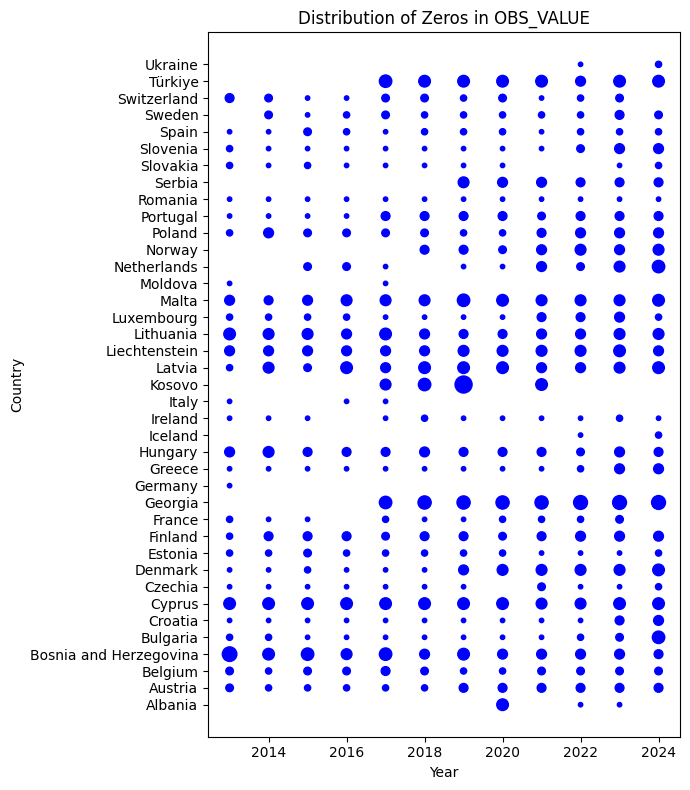

In [13]:
import matplotlib.pyplot as plt

zeros = df[df["OBS_VALUE"] == 0]
zero_counts = (
    zeros.groupby(["Geopolitical entity (reporting)", "TIME_PERIOD"])
    .size()
    .reset_index(name="zero_count")
)
zero_counts["Geopolitical entity (reporting)"] = zero_counts["Geopolitical entity (reporting)"].replace("Kosovo*", "Kosovo")

plt.figure(figsize=(7, 8))

plt.scatter(
    zero_counts["TIME_PERIOD"],
    zero_counts["Geopolitical entity (reporting)"],
    s=zero_counts["zero_count"] * 10,  # bubble size * 10 to improve visibility
    color="blue"
)

plt.xlabel("Year")
plt.ylabel("Country")
plt.title("Distribution of Zeros in OBS_VALUE")

plt.tight_layout()
plt.savefig("img/zeros_distrib_in_OBS_VALUE.png", dpi=300)
plt.show()

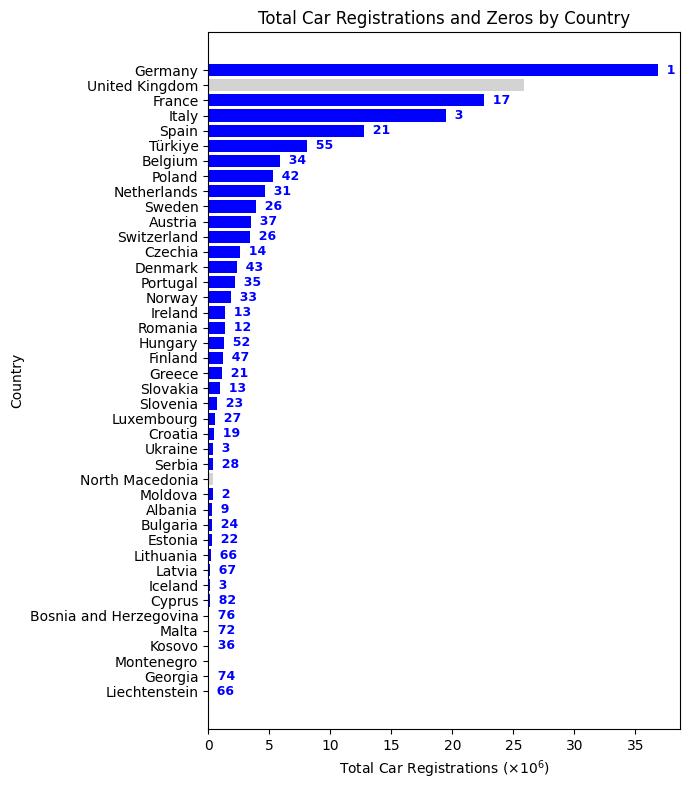

In [14]:
import matplotlib.pyplot as plt

total_registrations_per_country = (
    df[df["Motor energy"] == "Total"]
    .groupby("Geopolitical entity (reporting)")["OBS_VALUE"]
    .sum()
)
zero_observations_per_country = (
    df[df["OBS_VALUE"] == 0]
    .groupby("Geopolitical entity (reporting)")
    .size()
)

# [total_registrations, zero_observations]
plot_df = pd.DataFrame({
    "total_registrations": total_registrations_per_country,
    "zero_observations": zero_observations_per_country
}).fillna(0)
plot_df.rename(
    index={"Kosovo*": "Kosovo"},
    inplace=True
)
plot_df = plot_df.drop(
    index="European Union - 27 countries (from 2020)",
    errors="ignore"
)
plot_df = plot_df.sort_values("total_registrations")


fig, ax = plt.subplots(figsize=(7, 8))

# Blue bars for countries with zero observations, light gray for others
bar_colors = [
    "blue" if z > 0 else "lightgray"
    for z in plot_df["zero_observations"]
]

ax.barh(
    plot_df.index,
    plot_df["total_registrations"] / 1e6,
    color=bar_colors
)

# Labels for countries with zero observations
for country, registrations, zeros in zip(
    plot_df.index,
    plot_df["total_registrations"] / 1e6,
    plot_df["zero_observations"]
):
    if zeros > 0:
        ax.text(
            registrations,
            country,
            f"  {int(zeros)}",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="blue"
        )

ax.set_xlabel("Total Car Registrations ($\\times10^6$)")
ax.set_ylabel("Country")

ax.set_title("Total Car Registrations and Zeros by Country")

plt.tight_layout()
plt.savefig("img/total_car_registrations_and_zeros_by_country.png", dpi=300)
plt.show()

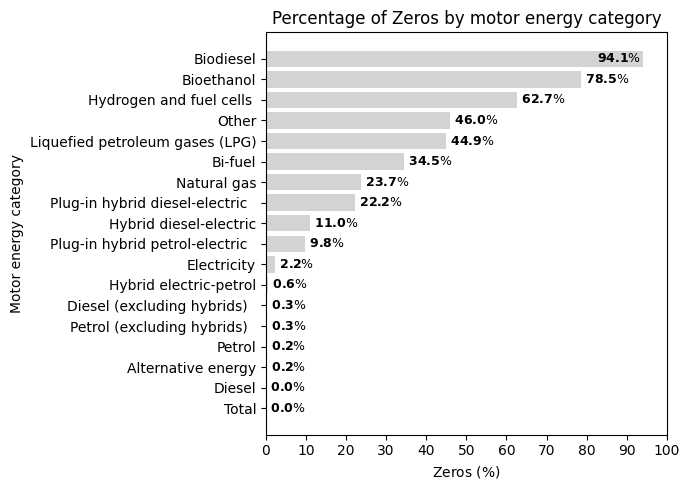

In [15]:
import matplotlib.pyplot as plt

# [total_observations, zero_observations]
plot_df = (
    df.groupby("Motor energy")["OBS_VALUE"]
    .agg(
        total_observations="count",
        zero_observations=lambda x: (x == 0).sum()
    )
)

# [total_observations, zero_observations, zero_percentage]
plot_df["zero_percentage"] = (
    plot_df["zero_observations"] /
    plot_df["total_observations"] * 100
)

plot_df.sort_values("zero_percentage", inplace=True)

plt.figure(figsize=(7, 5))

plt.barh(
    plot_df.index,
    plot_df["zero_percentage"],
    color="lightgrey"
)

# Add percentage labels
for category, value in zip(plot_df.index, plot_df["zero_percentage"]):
    # To avoid overlapping with the plot borders
    # If value is > 85, put it inside the bar
    if value > 85:
        plt.text(
            value - 0.5,
            category,
            f"{value:.1f}$\%$",
            va="center",
            ha="right",
            fontsize=9,
            fontweight="bold",
            color="black"
        )
    # Otherwise put it outside the bar
    else:
        plt.text(
            value,
            category,
            f" {value:.1f}$\%$",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold"
        )

plt.xlim(0, 100)
plt.xticks(range(0, 101, 10))

plt.xlabel("Zeros ($\%$)")
plt.ylabel("Motor energy category")
plt.title("Percentage of Zeros by motor energy category")

plt.tight_layout()
plt.savefig("img/percentage_of_zeros_by_motor_energy_category.png", dpi=300)
plt.show()

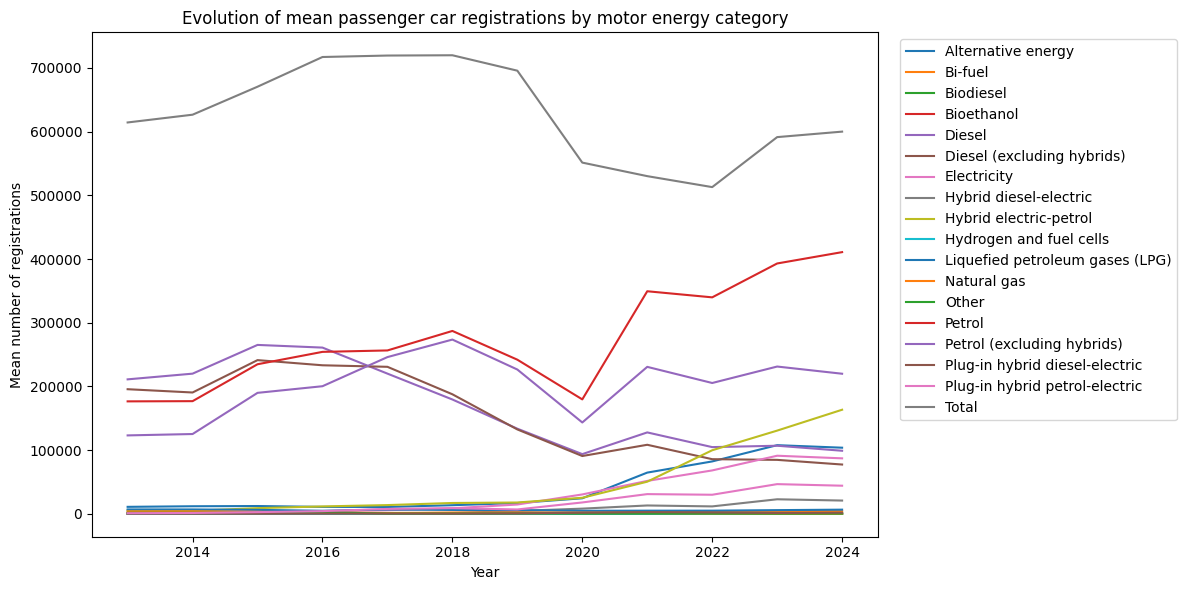

In [16]:
import matplotlib.pyplot as plt

# Mean registrations per year and motor energy category
pivot_df = df.groupby(["TIME_PERIOD", "Motor energy"])["OBS_VALUE"].mean().unstack()

pivot_df.plot(figsize=(12, 6))

plt.xlabel("Year")
plt.ylabel("Mean number of registrations")
plt.title("Evolution of mean passenger car registrations by motor energy category")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### NaN observations for the "OBS_VALUE" column

In [17]:
# Check for NaN values in the OBS_VALUE column
nan_obs_value = df[df["OBS_VALUE"].isna()]

display(nan_obs_value)

,Motor energy,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG
624,Bi-fuel,NO,Norway,2023,NaN,m


In [18]:
# Check Bi-fuel, Norway for all years
df[(df["Motor energy"] == "Bi-fuel") & (df["geo"] == "NO")]

,Motor energy,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG
619,Bi-fuel,NO,Norway,2018,0.0,NaN
620,Bi-fuel,NO,Norway,2019,0.0,NaN
621,Bi-fuel,NO,Norway,2020,0.0,NaN
622,Bi-fuel,NO,Norway,2021,0.0,NaN
623,Bi-fuel,NO,Norway,2022,0.0,NaN
624,Bi-fuel,NO,Norway,2023,NaN,m
625,Bi-fuel,NO,Norway,2024,0.0,NaN


In [19]:
# Substitute NaN for <Bi-fuel, NO, 2023> with 0.0
df.loc[(df["Motor energy"] == "Bi-fuel") & (df["geo"] == "NO") & (df["TIME_PERIOD"] == 2023), "OBS_VALUE"] = 0.0
df[(df["Motor energy"] == "Bi-fuel") & (df["geo"] == "NO")]

,Motor energy,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG
619,Bi-fuel,NO,Norway,2018,0.0,NaN
620,Bi-fuel,NO,Norway,2019,0.0,NaN
621,Bi-fuel,NO,Norway,2020,0.0,NaN
622,Bi-fuel,NO,Norway,2021,0.0,NaN
623,Bi-fuel,NO,Norway,2022,0.0,NaN
624,Bi-fuel,NO,Norway,2023,0.0,m
625,Bi-fuel,NO,Norway,2024,0.0,NaN


### Flags

- (i) is value imputed by Eurostat or other receiving agencies
- (e) is estimated
- (b) is break in time series
- (m) is missing value; data cannot exist.

In [20]:
flag_counts = (
    df["OBS_FLAG"]
    .value_counts(dropna=False)
    .rename_axis("Flag")
    .reset_index(name="Count")
)

flag_counts["Percentage"] = (
    flag_counts["Count"] / len(df) * 100
)

display(flag_counts)

,Flag,Count,Percentage
0,NaN,5541,87.896574
1,i,735,11.659264
2,b,16,0.253807
3,e,11,0.174492
4,m,1,0.015863


In [21]:
df[df["OBS_FLAG"] == "b"].sort_values(
    ["geo", "TIME_PERIOD"]
)

,Motor energy,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG
2442,Hybrid diesel-electric,BE,Belgium,2024,2703.0,b
2989,Hybrid electric-petrol,BE,Belgium,2024,103003.0,b
5118,Petrol,DK,Denmark,2020,138421.0,b
5941,Total,EL,Greece,2013,58659.0,b
164,Alternative energy,HR,Croatia,2013,272.0,b
540,Bi-fuel,HR,Croatia,2013,171.0,b
4817,Other,HR,Croatia,2013,98.0,b
6009,Total,HR,Croatia,2013,27802.0,b
321,Alternative energy,PL,Poland,2013,3525.0,b
1468,Diesel,PL,Poland,2013,102495.0,b


In [22]:
df[df["OBS_FLAG"]=="b"].groupby("TIME_PERIOD").size() # As most of the "b" flags are in 2013 it is suggested to consider data from 2014 onwards for analysis

TIME_PERIOD
2013    9
2020    1
2023    4
2024    2
dtype: int64

### Drop flag column

In [23]:
df.drop(columns=[
    'OBS_FLAG'
], inplace=True)

### Restrict from 2014 to 2024

In [24]:
df = df[df["TIME_PERIOD"] >= 2014]
df = df[df["TIME_PERIOD"] <= 2024]

df["TIME_PERIOD"].min(), df["TIME_PERIOD"].max()

(2014, 2024)

### Drop non EU27_2020 countries

In [25]:
eu27_2020 = ['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE']

# Check wether the df contains all the EU27_2020 countries
df_countries = df["geo"].unique().tolist()
all_countries_in_df = all(country in df_countries for country in eu27_2020)

print(all_countries_in_df) # True, all EU27_2020 countries are present in the dataset

True


In [26]:
# Filter the dataset to include only EU27_2020 countries
df = df[df["geo"].isin(eu27_2020)]

print(df["geo"].nunique()) # 27, only EU27_2020 countries are present in the dataset

27


### Decrease granularity of the dataset by aggregating the "Motor energy" column

- *Original values*: Alternative energy, Bi-fuel, Biodiesel, Bioethanol, Diesel, Diesel (excluding hybrids), Electricity, Hybrid diesel-electric, Plug-in hybrid diesel-electric, Hybrid electric-petrol, Plug-in hybrid petrol-electric, Natural gas, Hydrogen and fuel cells, Liquefied petroleum gases (LPG), Other, Petrol, Petrol (excluding hybrids), Total
- *Aggregated values*: Diesel, Diesel (excluding hybrids), Diesel hybrid, Diesel plug-in hybrid, Petrol, Petrol (excluding hybrids), Petrol hybrid, Petrol plug-in hybrid, Electricity, Total

In [27]:
# Clean the "Motor energy" column by removing non-breaking spaces and stripping whitespace
df["Motor energy"] = (
    df["Motor energy"]
    .str.replace("\xa0", "", regex=False)
    .str.strip()
)

In [28]:
motor_energy_map = {
    "Alternative energy": "Alternative/Other",
    "Bi-fuel": "Alternative/Other",
    "Biodiesel": "Alternative/Other",
    "Bioethanol": "Alternative/Other",
    "Natural gas": "Alternative/Other",
    "Hydrogen and fuel cells": "Alternative/Other",
    "Liquefied petroleum gases (LPG)": "Alternative/Other",
    "Other": "Alternative/Other",

    "Diesel": "Diesel (all)",
    "Diesel (excluding hybrids)": "Diesel (excluding hybrids)",
    "Hybrid diesel-electric": "Diesel hybrid",
    "Plug-in hybrid diesel-electric": "Diesel plug-in hybrid",

    "Petrol": "Petrol (all)",
    "Petrol (excluding hybrids)": "Petrol (excluding hybrids)",
    "Hybrid electric-petrol": "Petrol hybrid",
    "Plug-in hybrid petrol-electric": "Petrol plug-in hybrid",

    "Electricity": "Electricity",

    "Total": "Total"
}
df["Motor energy"] = df["Motor energy"].replace(motor_energy_map)

df["Motor energy"].unique()

array(['Alternative/Other', 'Diesel (all)', 'Diesel (excluding hybrids)',
       'Electricity', 'Diesel hybrid', 'Diesel plug-in hybrid',
       'Petrol hybrid', 'Petrol plug-in hybrid', 'Petrol (all)',
       'Petrol (excluding hybrids)', 'Total'], dtype=object)

### Analysis on the detailed and aggregated "Motor energy" categories (Diesel, Petrol)

For "TIME_PERIOD" <= 2021, the sum of the "OBS_VALUE" column for detailed categories (i.e. Diesel (excluding hybrids), Diesel hybrid, Diesel plug-in hybrid) does not match the aggregated categories (i.e. Diesel). 

This is because before 2021 memeber states were not required to report the detailed categories, so the aggregated categories were reported instead. Some member states reported the detailed categories, while others reported the aggregated categories.

In [29]:
MOTOR_ENERGY = "Petrol" # Choose "Petrol" or "Diesel"

comparison_df = (
    df[df["Motor energy"].str.startswith(MOTOR_ENERGY)]
    .pivot_table(
        index="TIME_PERIOD",
        columns="Motor energy",
        values="OBS_VALUE",
        aggfunc="sum",
    )
)

# Check if the sum of detailed categories matches the aggregated category
comparison_df["Sum of " + MOTOR_ENERGY + " detailed categories"] = (
    comparison_df[MOTOR_ENERGY + " (excluding hybrids)"]
    + comparison_df[MOTOR_ENERGY + " hybrid"]
    + comparison_df[MOTOR_ENERGY + " plug-in hybrid"]
)
comparison_df["Difference"] = comparison_df[MOTOR_ENERGY + " (all)"] - comparison_df["Sum of " + MOTOR_ENERGY + " detailed categories"]

comparison_df[[MOTOR_ENERGY + " (all)", "Sum of " + MOTOR_ENERGY + " detailed categories", "Difference"]]

Motor energy,Petrol (all),Sum of Petrol detailed categories,Difference
TIME_PERIOD,,,
2014,4133516.0,2330031.0,1803485.0
2015,4710893.0,2770472.0,1940421.0
2016,5428866.0,3366648.0,2062218.0
2017,6436612.0,6125736.0,310876.0
2018,7393615.0,7059215.0,334400.0
2019,7944541.0,7864981.0,79560.0
2020,6179844.0,5991835.0,188009.0
2021,6328815.0,6328815.0,0.0
2022,6014361.0,6014361.0,0.0


In [30]:
YEAR = 2023

tmp = df[df["TIME_PERIOD"] == YEAR]

tmp.groupby("Motor energy")["OBS_VALUE"].sum()

Motor energy
Alternative/Other              2179270.0
Diesel (all)                   1957434.0
Diesel (excluding hybrids)     1497870.0
Diesel hybrid                   420406.0
Diesel plug-in hybrid            39160.0
Electricity                    1547676.0
Petrol (all)                   6834609.0
Petrol (excluding hybrids)     3792528.0
Petrol hybrid                  2310511.0
Petrol plug-in hybrid           731570.0
Total                         10654675.0
Name: OBS_VALUE, dtype: float64

**How do we handle this?** Maybe:
- if there is a 0 in the detailed categories, then take the value from the aggregated category because the detailed are not correct
- if detailed categories are != 0, we can use detailed categories for better analysis

In [31]:
df.to_csv('../data/cleaned/2c_eurostat_new_passenger_cars_by_type_of_motor_energy.csv', index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4138 entries, 7 to 6269
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Motor energy                     4138 non-null   object 
 1   geo                              4138 non-null   object 
 2   Geopolitical entity (reporting)  4138 non-null   object 
 3   TIME_PERIOD                      4138 non-null   int64  
 4   OBS_VALUE                        4138 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 194.0+ KB
